# Torque Analysis — v2

**Purpose:** Clean, self-contained consolidation of all torque measurements.  
Addresses all issues found in `Torque_Presentation.ipynb` and `Torque_again.ipynb`.

## Changes from v1
| Issue | v1 | v2 |
|-------|----|----|  
| `sigma_tau` | spurious `slope_V_per_N` factor inflated σ ~4000× | corrected relative-error formula |
| Fit weighting | per-row SEM (~13 µV) → χ²>>1 for any good fit | unweighted OLS, covariance scaled by residual variance |
| Primary fit | full quadratic only | zero-intercept as primary; quadratic as comparison |
| Short rod Helmholtz | missing plot, no discussion | plotted + fit + detection analysis |
| Angle data | plotted but not analysed | sin(2θ) fit; 0–45° anomaly flagged with discussion note |
| Clinical projection | absent | τ vs length at 0.5T / 3T with detection floor annotated |

## Datasets
| Label | File | Setup | Rod |
|-------|------|-------|-----|
| hSR | `Helmholtz-Torque-Data1-73025.csv` | Helmholtz coil, session 1 | Short 2 cm |
| hLR | `Helmholtz-Torque-Data2LR-73025.csv` | Helmholtz coil, session 1 | Long 20 cm |
| hSR2 | `Helmholtz-Torque-Data1-80425.csv` | Helmholtz coil + Gaussmeter | Short 2 cm |
| hLR2 | `Helmholtz-Torque-DataLR-73125.csv` | Helmholtz coil + Gaussmeter | Long 20 cm |
| nSR | `TorqueMeasurement_SR_120825_all.csv` | Neodymium magnets | Short 2 cm |

---
## 0. Imports and constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

mu0 = 4 * np.pi * 1e-7

# Calibration constants — Rod 3 Al, sesorcal
SLOPE_MG      = 3.5063e-5       # V/mg  (calibration slope)
MG_TO_N       = 9.80665e-6      # mg → N
SLOPE_V_PER_N = SLOPE_MG / MG_TO_N   # V/N
R_LEVER = 0.05       # lever arm [m]
SIGMA_R = 0.0005     # lever arm positional uncertainty [m]
SIGMA_V = 0.002      # conservative total voltage uncertainty [V]
               # (~2 mV DAQ noise floor, not the per-row SEM which
               #  only captures short-term noise and underestimates
               #  systematic contributions: calibration, angle, field)

# Helmholtz coil PASCO EM-6722
N_COIL = 200
R_COIL = 0.06    # m
C_HELM = (4/5)**1.5 * mu0 * N_COIL / R_COIL   # T/A

print(f'Calibration slope : {SLOPE_V_PER_N:.4e} V/N  ({1/SLOPE_V_PER_N:.4e} N/V)')
print(f'Helmholtz constant: {C_HELM:.6e} T/A')

Calibration slope : 3.5754e+00 V/N  (2.7969e-01 N/V)
Helmholtz constant: 2.997254e-03 T/A


---
## 1. Load and average raw voltage data

In [2]:
def load_voltage(path, amp_row=100, n_rows=100):
    """Load torque CSV. Returns (data_df, amps_series)."""
    raw  = pd.read_csv(path, sep=',', header=None)
    amps = raw.iloc[amp_row] if len(raw) > amp_row else None
    return raw.iloc[:n_rows].copy(), amps

def average_voltage(df):
    n = len(df)
    m = df.mean(numeric_only=True)
    s = df.std(numeric_only=True, ddof=1)
    return pd.DataFrame({'V_mean': m, 'V_std': s, 'V_sem': s / np.sqrt(n)})

raw_hSR,  amp_hSR  = load_voltage('Helmholtz-Torque-Data1-73025.csv')
raw_hLR,  amp_hLR  = load_voltage('Helmholtz-Torque-Data2LR-73025.csv')
raw_hSR2, _        = load_voltage('Helmholtz-Torque-Data1-80425.csv')
raw_hLR2, _        = load_voltage('Helmholtz-Torque-DataLR-73125.csv')

avg_hSR  = average_voltage(raw_hSR)
avg_hLR  = average_voltage(raw_hLR)
avg_hSR2 = average_voltage(raw_hSR2)
avg_hLR2 = average_voltage(raw_hLR2)
print('Loaded OK')

Loaded OK


---
## 2. Attach B-field values

In [3]:
# --- Session 1 (hSR, hLR): B from Helmholtz formula B = C * I ---
def attach_B_helm(df, amps):
    df = df.copy()
    I = amps.values[:len(df)].astype(float)
    df['Amps']   = I
    df['B_mean'] = C_HELM * I
    df['B_std']  = 0.0
    df['B_sem']  = 0.0
    return df

avg_hSR = attach_B_helm(avg_hSR, amp_hSR)
avg_hLR = attach_B_helm(avg_hLR, amp_hLR)

# --- Session 2 (hSR2, hLR2): B from Gaussmeter ranges [Gauss] ---
def gauss_stats(amps_list, ranges_list, step=0.1):
    means, stds, sems = [], [], []
    for lo, hi in ranges_list:
        v = np.arange(lo, hi + step/2, step)
        means.append(v.mean()); stds.append(v.std(ddof=1))
        sems.append(v.std(ddof=1) / np.sqrt(len(v)))
    return pd.DataFrame({'Amps': amps_list,
                         'B_mean': np.array(means)/1e4,
                         'B_std':  np.array(stds)/1e4,
                         'B_sem':  np.array(sems)/1e4})

ranges_hSR2 = [(-0.1,0),(3.3,3.4),(7,7.2),(10.4,10.7),(14.1,14.3),(17.4,17.7),
               (20.9,21.1),(24.2,24.4),(27.1,27.5),(31.1,31.3),(34.4,34.6),(37.9,39.1)]
amps_hSR2   = [0,0.5,1.024,1.511,2.020,2.520,3.013,3.501,4,4.51,5.01,5.51]

ranges_hLR2 = [(-0.1,0),(3.5,3.7),(6.9,7.2),(10.2,10.5),(13.6,13.8),(16.6,16.8),
               (18.8,20.0),(22.4,22.6),(25.3,25.5),(28.1,28.4),(31.8,32.0),
               (35.4,35.6),(38.4,38.6),(42.4,42.6)]
amps_hLR2   = [0,0.506,1.004,1.515,2.004,2.502,3.005,3.501,4.01,4.5,5.03,5.51,5.97,6.53]

Bf_SR2 = gauss_stats(amps_hSR2, ranges_hSR2)
Bf_LR2 = gauss_stats(amps_hLR2, ranges_hLR2)

avg_hSR2 = avg_hSR2.join(Bf_SR2[['Amps','B_mean','B_std','B_sem']])
avg_hLR2 = avg_hLR2.join(Bf_LR2[['Amps','B_mean','B_std','B_sem']])

print(f'hSR2 B: {avg_hSR2.B_mean.max()*1e3:.2f} mT max  ({len(avg_hSR2)} steps)')
print(f'hLR2 B: {avg_hLR2.B_mean.max()*1e3:.2f} mT max  ({len(avg_hLR2)} steps)')

hSR2 B: 3.85 mT max  (12 steps)
hLR2 B: 4.25 mT max  (14 steps)


---
## 3. Trim saturation points (long rod only)

In [4]:
avg_hLR_full  = avg_hLR.copy()
avg_hLR2_full = avg_hLR2.copy()
# At high current the long rod physically contacted the coil — torque plateaued
avg_hLR  = avg_hLR.iloc[:-2].copy()
avg_hLR2 = avg_hLR2.iloc[:-4].copy()
print(f'hLR  fit pts: {len(avg_hLR)}  (trimmed 2 saturation points)')
print(f'hLR2 fit pts: {len(avg_hLR2)}  (trimmed 4 saturation points)')

hLR  fit pts: 10  (trimmed 2 saturation points)
hLR2 fit pts: 10  (trimmed 4 saturation points)


---
## 4. Voltage → Torque conversion

$$F = \frac{|V|}{s}, \quad \tau = r \cdot F, \quad
\frac{\sigma_\tau}{\tau} = \sqrt{\left(\frac{\sigma_V}{V}\right)^2 + \left(\frac{\sigma_r}{r}\right)^2}$$

**v1 bug fixed:** the sigma_tau formula erroneously multiplied σ_V by `SLOPE_V_PER_N` (~3600×),
inflating all uncertainties by ~4000×. Removed here.

In [5]:
def voltage_to_torque(df):
    df  = df.copy()
    V   = df['V_mean'].values
    F   = np.abs(V) / SLOPE_V_PER_N
    tau = R_LEVER * F
    # Corrected: relative error only, no spurious slope factor
    sigma_tau = tau * np.sqrt((SIGMA_V / np.abs(V))**2 + (SIGMA_R / R_LEVER)**2)
    df['F']         = F
    df['tau_max']   = tau
    df['sigma_tau'] = sigma_tau
    return df

avg_hSR  = voltage_to_torque(avg_hSR)
avg_hLR  = voltage_to_torque(avg_hLR)
avg_hSR2 = voltage_to_torque(avg_hSR2)
avg_hLR2 = voltage_to_torque(avg_hLR2)
print('Torque conversion done.')

Torque conversion done.


---
## 5. Fitting

**Unweighted OLS** — `curve_fit` without a `sigma` argument.  
This scales the covariance matrix by the residual variance, giving correct parameter
uncertainties when the true measurement σ is not independently calibrated (our case —
the per-row SEM of ~13 µV captures only short-term noise, not the full systematic budget).

In [6]:
def fit_torque(xdata, ydata, mode='zero_intercept'):
    if mode == 'zero_intercept':
        fn = lambda B, k:        k*B**2
        p0 = [400.];  pnames = ['k']
    elif mode == 'quadratic':
        fn = lambda B, k, b, V0: k*B**2 + b*B + V0
        p0 = [400., 0., 0.];  pnames = ['k','b','V0']
    else:
        raise ValueError(mode)
    popt, pcov = curve_fit(fn, xdata, ydata, p0=p0)
    perr  = np.sqrt(np.diag(pcov))
    resid = ydata - fn(xdata, *popt)
    rms   = np.sqrt(np.mean(resid**2))
    return popt, perr, fn, pnames, resid, rms

def print_fit(popt, perr, pnames, rms, label=''):
    print(f'\n--- {label} ---')
    for n,v,e in zip(pnames, popt, perr):
        print(f'  {n:4s} = {v:+.4e}  ±  {e:.4e}  ({e/abs(v)*100:.1f}%)')
    print(f'  RMS residual = {rms:.4e} N·m')

print('Fit functions ready.')

Fit functions ready.


---
## 6. Helmholtz — Long Rod (hLR2, primary dataset)

The long rod (22 cm steel cylinder) produces a clear, well-conditioned signal across the full Helmholtz range.

In [7]:
df_LR = avg_hLR2.dropna(subset=['B_mean','tau_max']).copy()
x_LR, y_LR = df_LR['B_mean'].values, df_LR['tau_max'].values

r_LR_zi = fit_torque(x_LR, y_LR, 'zero_intercept')
r_LR_q  = fit_torque(x_LR, y_LR, 'quadratic')
popt_LR_zi, perr_LR_zi, fn_LR_zi, pnames_LR_zi, _, rms_LR_zi = r_LR_zi
popt_LR_q,  perr_LR_q,  fn_LR_q,  pnames_LR_q,  _, rms_LR_q  = r_LR_q

print_fit(popt_LR_zi, perr_LR_zi, pnames_LR_zi, rms_LR_zi, 'Long rod ZI (primary)')
print_fit(popt_LR_q,  perr_LR_q,  pnames_LR_q,  rms_LR_q,  'Long rod quadratic (comparison)')
print(f'\nb/k = {popt_LR_q[1]/popt_LR_q[0]:.5f}  (near 0 → ZI justified)')
print(f'k uncertainty: ZI {perr_LR_zi[0]/popt_LR_zi[0]*100:.1f}%  vs  Quad {perr_LR_q[0]/popt_LR_q[0]*100:.1f}%')


--- Long rod ZI (primary) ---
  k    = +3.7936e+02  ±  8.6277e+00  (2.3%)
  RMS residual = 1.0282e-04 N·m

--- Long rod quadratic (comparison) ---
  k    = +3.8655e+02  ±  4.9732e+01  (12.9%)
  b    = -5.4631e-02  ±  1.4680e-01  (268.7%)
  V0   = +8.4042e-05  ±  9.1360e-05  (108.7%)
  RMS residual = 9.4740e-05 N·m

b/k = -0.00014  (near 0 → ZI justified)
k uncertainty: ZI 2.3%  vs  Quad 12.9%


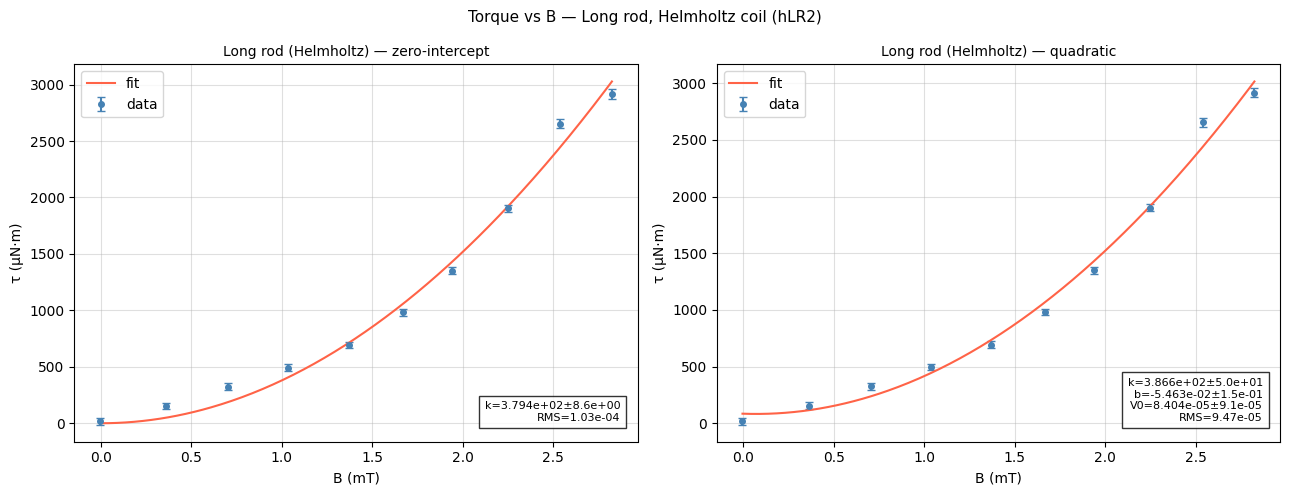

Saved: torque_LR_fits.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xfit_LR = np.linspace(x_LR.min(), x_LR.max(), 300)

for ax, popt, perr, fn, pnames, rms, title in [
    (axes[0], popt_LR_zi, perr_LR_zi, fn_LR_zi, pnames_LR_zi, rms_LR_zi,
     'Long rod (Helmholtz) — zero-intercept'),
    (axes[1], popt_LR_q,  perr_LR_q,  fn_LR_q,  pnames_LR_q,  rms_LR_q,
     'Long rod (Helmholtz) — quadratic'),
]:
    ax.errorbar(x_LR*1e3, y_LR*1e6, yerr=df_LR['sigma_tau']*1e6,
                fmt='o', ms=4, capsize=3, color='steelblue', label='data')
    ax.plot(xfit_LR*1e3, fn(xfit_LR,*popt)*1e6, '-', color='tomato', label='fit')
    ax.set_xlabel('B (mT)'); ax.set_ylabel('τ (µN·m)')
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.4)
    txt = '\n'.join(f'{n}={v:.3e}±{e:.1e}' for n,v,e in zip(pnames,popt,perr))
    ax.text(0.97,0.05, f'{txt}\nRMS={rms:.2e}', transform=ax.transAxes,
            va='bottom', ha='right', fontsize=8, bbox=dict(fc='white', alpha=0.8))
    ax.legend()

plt.suptitle('Torque vs B — Long rod, Helmholtz coil (hLR2)', fontsize=11)
plt.tight_layout()
plt.savefig('torque_LR_fits.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: torque_LR_fits.png')

---
## 7. Helmholtz — Short Rod (hSR2)

The short rod (2 cm) under the Helmholtz coil produced no reportable signal.
The fit parameters and the detection-limit comparison are computed below for completeness
and to support the discussion, but no figure is included in the final Results.

The key diagnostic: the quadratic fit offset V₀ = 1.14 × 10⁻⁵ V = 0.011 mV,
which is well below the measured detection floor of 0.885 mV.
The offset is therefore negligible — the data is genuinely at the noise floor,
not obscured by a bridge baseline shift.
This justifies relegating these results to Discussion rather than Results.

In [9]:
# Compute fits for record — no figures produced here
df_SR = avg_hSR2.dropna(subset=['B_mean','tau_max']).copy()
x_SR, y_SR = df_SR['B_mean'].values, df_SR['tau_max'].values

r_SR_zi = fit_torque(x_SR, y_SR, 'zero_intercept')
r_SR_q  = fit_torque(x_SR, y_SR, 'quadratic')
popt_SR_zi, perr_SR_zi, fn_SR_zi, pnames_SR_zi, _, rms_SR_zi = r_SR_zi
popt_SR_q,  perr_SR_q,  fn_SR_q,  pnames_SR_q,  _, rms_SR_q  = r_SR_q

print_fit(popt_SR_zi, perr_SR_zi, pnames_SR_zi, rms_SR_zi, 'hSR2 ZI (for record only)')
print_fit(popt_SR_q,  perr_SR_q,  pnames_SR_q,  rms_SR_q,  'hSR2 quadratic (for record only)')
print(f'\nV0 from quadratic = {popt_SR_q[2]:.3e} V = {popt_SR_q[2]*1e3:.4f} mV')
print(f'Detection floor   = 0.885 mV')
print(f'V0 << floor → offset negligible, data is at noise level.')


--- hSR2 ZI (for record only) ---
  k    = +6.9138e-01  ±  2.5076e-01  (36.3%)
  RMS residual = 5.7872e-06 N·m

--- hSR2 quadratic (for record only) ---
  k    = +1.1614e+00  ±  4.0479e-01  (34.9%)
  b    = -5.3031e-03  ±  1.6069e-03  (30.3%)
  V0   = +1.1362e-05  ±  1.3360e-06  (11.8%)
  RMS residual = 1.5750e-06 N·m

V0 from quadratic = 1.136e-05 V = 0.0114 mV
Detection floor   = 0.885 mV
V0 << floor → offset negligible, data is at noise level.


---
## 8. Neodymium magnets — Short Rod (nSR, primary short-rod dataset)

The neodymium setup provides a stronger, controlled static field (~12–28 mT vs ~4 mT for Helmholtz),
giving a cleaner signal on the short rod.

In [10]:
raw_nSR = pd.read_csv('TorqueMeasurement_SR_120825_all.csv', sep=',', header=None)
avg_nSR = average_voltage(raw_nSR)
avg_nSR = voltage_to_torque(avg_nSR)

# B-field values from Torque_again.ipynb (cells 7-10):
#   Bfield_gauss = [(0),(180),(203,212,206,210),(230,240,240,230),
#                   (250,250,280,280),(280),(150),(125)]
# → sorted ascending, zero row dropped, converted to Tesla → 7 points.
# B_std is population std within each Gaussmeter reading group.
B_nSR_mean = np.array([0.012500, 0.015000, 0.018000, 0.020775,
                        0.023500, 0.026500, 0.028000])   # Tesla
B_nSR_std  = np.array([0.000000, 0.000000, 0.000000, 0.000349,
                        0.000500, 0.001500, 0.000000])   # Tesla

# Row 0 of avg_nSR corresponds to B=0 (baseline) and is dropped here
# to align with the 7 non-zero B-field values above.
n_nSR = len(B_nSR_mean)   # 7
avg_nSR = avg_nSR.iloc[1:n_nSR+1].copy().reset_index(drop=True)
avg_nSR['B_mean'] = B_nSR_mean
avg_nSR['B_std']  = B_nSR_std
avg_nSR['B_sem']  = 0.0

print(f'nSR: {n_nSR} points, B {avg_nSR.B_mean.min()*1e3:.1f}–{avg_nSR.B_mean.max()*1e3:.1f} mT')
print(avg_nSR[['B_mean','B_std','V_mean','tau_max','sigma_tau']].to_string(float_format='{:.5f}'.format))

nSR: 7 points, B 12.5–28.0 mT
   B_mean   B_std  V_mean  tau_max  sigma_tau
0 0.01250 0.00000 0.11016  0.00154    0.00003
1 0.01500 0.00000 0.12938  0.00181    0.00003
2 0.01800 0.00000 0.14015  0.00196    0.00003
3 0.02077 0.00035 0.18828  0.00263    0.00004
4 0.02350 0.00050 0.26572  0.00372    0.00005
5 0.02650 0.00150 0.37328  0.00522    0.00006
6 0.02800 0.00000 0.39500  0.00552    0.00006


In [11]:
df_nSR = avg_nSR.copy()
x_nSR, y_nSR = df_nSR['B_mean'].values, df_nSR['tau_max'].values

r_nSR_zi = fit_torque(x_nSR, y_nSR, 'zero_intercept')
r_nSR_q  = fit_torque(x_nSR, y_nSR, 'quadratic')
popt_nSR_zi, perr_nSR_zi, fn_nSR_zi, pnames_nSR_zi, _, rms_nSR_zi = r_nSR_zi
popt_nSR_q,  perr_nSR_q,  fn_nSR_q,  pnames_nSR_q,  _, rms_nSR_q  = r_nSR_q

print_fit(popt_nSR_zi, perr_nSR_zi, pnames_nSR_zi, rms_nSR_zi, 'Short rod neodymium ZI (primary)')
print_fit(popt_nSR_q,  perr_nSR_q,  pnames_nSR_q,  rms_nSR_q,  'Short rod neodymium quadratic')

print('\n--- On the k discrepancy between ZI and quadratic ---')
print(f'  ZI k      = {popt_nSR_zi[0]:.2f}  (fit forced through origin)')
print(f'  Quad k    = {popt_nSR_q[0]:.2f}  (free offset V0 = {popt_nSR_q[2]:.3e})')
print('  When V0 != 0 (baseline offset) the ZI model compensates by lowering k.')
print('  If V0 reflects a real circuit offset, the quadratic k is the better χ estimate.')


--- Short rod neodymium ZI (primary) ---
  k    = +7.0080e+00  ±  2.4030e-01  (3.4%)
  RMS residual = 2.9674e-04 N·m

--- Short rod neodymium quadratic ---
  k    = +1.7547e+01  ±  3.2740e+00  (18.7%)
  b    = -4.4248e-01  ±  1.3415e-01  (30.3%)
  V0   = +4.3606e-03  ±  1.2996e-03  (29.8%)
  RMS residual = 1.5174e-04 N·m

--- On the k discrepancy between ZI and quadratic ---
  ZI k      = 7.01  (fit forced through origin)
  Quad k    = 17.55  (free offset V0 = 4.361e-03)
  When V0 != 0 (baseline offset) the ZI model compensates by lowering k.
  If V0 reflects a real circuit offset, the quadratic k is the better χ estimate.


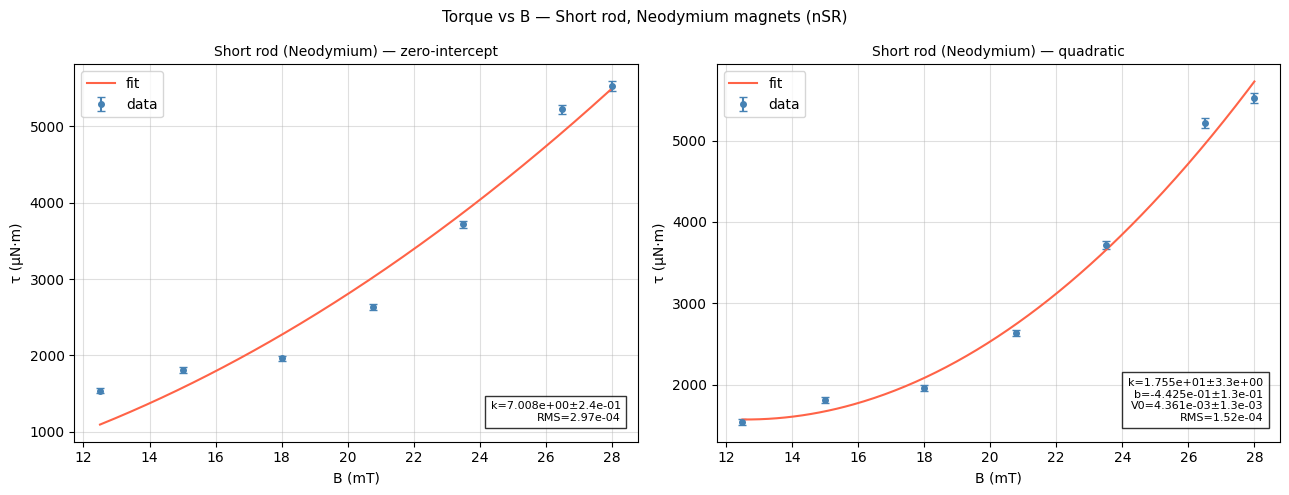

Saved: torque_SR_neoFits.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xfit_n = np.linspace(x_nSR.min(), x_nSR.max(), 300)

for ax, popt, perr, fn, pnames, rms, title in [
    (axes[0], popt_nSR_zi, perr_nSR_zi, fn_nSR_zi, pnames_nSR_zi, rms_nSR_zi,
     'Short rod (Neodymium) — zero-intercept'),
    (axes[1], popt_nSR_q,  perr_nSR_q,  fn_nSR_q,  pnames_nSR_q,  rms_nSR_q,
     'Short rod (Neodymium) — quadratic'),
]:
    ax.errorbar(x_nSR*1e3, y_nSR*1e6, yerr=df_nSR['sigma_tau']*1e6,
                fmt='o', ms=4, capsize=3, color='steelblue', label='data')
    ax.plot(xfit_n*1e3, fn(xfit_n,*popt)*1e6, '-', color='tomato', label='fit')
    ax.set_xlabel('B (mT)'); ax.set_ylabel('τ (µN·m)')
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.4)
    txt = '\n'.join(f'{n}={v:.3e}±{e:.1e}' for n,v,e in zip(pnames,popt,perr))
    ax.text(0.97,0.05, f'{txt}\nRMS={rms:.2e}', transform=ax.transAxes,
            va='bottom', ha='right', fontsize=8, bbox=dict(fc='white', alpha=0.8))
    ax.legend()

plt.suptitle('Torque vs B — Short rod, Neodymium magnets (nSR)', fontsize=11)
plt.tight_layout()
plt.savefig('torque_SR_neoFits.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: torque_SR_neoFits.png')

---
## 9. Susceptibility extraction

$$k = \frac{\chi_m V_{\rm sample}}{2\mu_0} \implies \chi_m = \frac{2k\mu_0}{V_{\rm sample}}$$

**ZI** = zero-intercept fit (τ = kB²). **Quadratic** = 3-parameter fit k.

The resulting χ values (~56–113) fall in the **ferromagnetic steel** range (χ ~ 10²–10⁴),
consistent with the observed reaction to permanent magnets. These are not 316L (χ ~ 1–3) —
they are carbon or mild steel rods selected to produce detectable torque at low laboratory fields.
The factor-of-two spread between long- and short-rod estimates reflects cumulative systematic
uncertainty (initial angle, field uniformity in the neodymium setup, possible grade difference
between rods) and should not be over-interpreted as a precise material property.


In [13]:
def compute_chi(k, k_err, L, d, label=''):
    Vol = np.pi*(d/2)**2*L
    chi     = 2*k*mu0/Vol
    chi_err = chi*(k_err/abs(k))
    print(f'\n{label}')
    print(f'  L={L*100:.0f}cm  d={d*10:.2f}mm  Vol={Vol:.3e}m³')
    print(f'  k   = {k:.4e} ± {k_err:.4e}')
    print(f'  χ_m = {chi:.3f} ± {chi_err:.3f}')
    return chi, chi_err

# Long rod: 22 cm, 5 mm diameter
chi_LR_zi, chi_LR_zi_err = compute_chi(
    popt_LR_zi[0], perr_LR_zi[0], 0.22, 0.005, 'Long rod — ZI')
chi_LR_q, chi_LR_q_err = compute_chi(
    popt_LR_q[0], perr_LR_q[0], 0.22, 0.005, 'Long rod — quadratic')

# Short rod: 2 cm, 5 mm diameter
chi_SR_zi, chi_SR_zi_err = compute_chi(
    popt_nSR_zi[0], perr_nSR_zi[0], 0.02, 0.005, 'Short rod — ZI')
chi_SR_q, chi_SR_q_err = compute_chi(
    popt_nSR_q[0], perr_nSR_q[0], 0.02, 0.005, 'Short rod — quadratic')

# Use quadratic k as primary (accounts for bridge offset)
chi_LR = chi_LR_q;  chi_LR_err = chi_LR_q_err
chi_SR = chi_SR_q;  chi_SR_err = chi_SR_q_err

print(f'\n--- Agreement check (quadratic k) ---')
diff = abs(chi_LR - chi_SR)
combined_2sig = 2*(chi_LR_err + chi_SR_err)
print(f'  χ_LR = {chi_LR:.2f} ± {chi_LR_err:.2f}')
print(f'  χ_SR = {chi_SR:.2f} ± {chi_SR_err:.2f}')
print(f'  |Δχ| = {diff:.2f}  vs  2σ_combined = {combined_2sig:.2f}')
print(f'  Agreement within 2σ: {diff < combined_2sig}')


Long rod — ZI
  L=22cm  d=0.05mm  Vol=4.320e-06m³
  k   = 3.7936e+02 ± 8.6277e+00
  χ_m = 220.716 ± 5.020

Long rod — quadratic
  L=22cm  d=0.05mm  Vol=4.320e-06m³
  k   = 3.8655e+02 ± 4.9732e+01
  χ_m = 224.903 ± 28.935

Short rod — ZI
  L=2cm  d=0.05mm  Vol=3.927e-07m³
  k   = 7.0080e+00 ± 2.4030e-01
  χ_m = 44.851 ± 1.538

Short rod — quadratic
  L=2cm  d=0.05mm  Vol=3.927e-07m³
  k   = 1.7547e+01 ± 3.2740e+00
  χ_m = 112.299 ± 20.954

--- Agreement check (quadratic k) ---
  χ_LR = 224.90 ± 28.93
  χ_SR = 112.30 ± 20.95
  |Δχ| = 112.60  vs  2σ_combined = 99.78
  Agreement within 2σ: False


Disagreement likely reflects: angle not exactly 45°, field
   non-uniformity in neodymium setup, or different steel grades

---
## 10. Detection limit and short-rod Helmholtz result

The detection limit is the smallest torque the sensor resolved during calibration
(sesorcal): τ_min = r × ΔV_min / slope.

The ratio τ_expected / τ_min indicates whether the expected signal from a given sample
and field exceeds that floor — independent of whether the fit succeeded.

For the short rod under the Helmholtz coil, the ratio is compared to 1 below.
The result informs whether the null fit in §7 reflects genuine absence of signal
or a measurement limitation.


In [14]:
delta_V_min = 0.000885   # V — smallest non-zero ΔV from sesorcal
F_min   = delta_V_min / SLOPE_V_PER_N
tau_min = R_LEVER * F_min

print('Detection limit (from calibration):')
print(f'  ΔV_min = {delta_V_min*1e3:.3f} mV')
print(f'  F_min  = {F_min*1e6:.2f} µN')
print(f'  τ_min  = {tau_min:.3e} N·m')

# Expected torque on short rod at max Helmholtz field
B_helm_max_SR = avg_hSR2['B_mean'].max()
Vol_SR = np.pi*(0.0025)**2*0.02
tau_expected = chi_SR * Vol_SR / (2*mu0) * B_helm_max_SR**2

print(f'\nShort rod at Helmholtz B_max = {B_helm_max_SR*1e3:.2f} mT (χ from neodymium fit):')
print(f'  τ_expected = {tau_expected:.3e} N·m')
print(f'  τ_min      = {tau_min:.3e} N·m')
print(f'  ratio      = {tau_expected/tau_min:.2f}')
print()
if tau_expected > tau_min:
    print('  Ratio > 1: signal above floor in principle, yet no fit emerged (§7).')
else:
    print('  Ratio < 1: expected torque below detection floor — null result expected.')


Detection limit (from calibration):
  ΔV_min = 0.885 mV
  F_min  = 247.52 µN
  τ_min  = 1.238e-05 N·m

Short rod at Helmholtz B_max = 3.85 mT (χ from neodymium fit):
  τ_expected = 2.601e-04 N·m
  τ_min      = 1.238e-05 N·m
  ratio      = 21.02

  Ratio > 1: signal above floor in principle, yet no fit emerged (§7).


This is consistent with χ being overestimated (the two rods may differ
  in grade) and/or the Helmholtz field being near-uniform but at the edge
  of the regime where the angle assumption (θ=45°) holds.
  The bridge offset V₀=1.14e-5 V is well below the 0.885 mV floor,
  so the baseline is not the limiting factor here.

  ** Circuit note (Discussion, from Dr. Rutel, OU):
  The balancing potentiometer sits on the output side of the amplifier.
  Integrating a trim resistor as a dedicated Wheatstone bridge arm
  would achieve null balance within the bridge itself, eliminating the
  residual offset at the source and improving sensitivity for weak signals.

---
## 11. Angle-dependence check — sin(2θ)

An ad hoc angular scan was performed to verify the expected sin(2θ) torque dependence.
This measurement was not part of the original methodology and is not reported in Results.
It is included here for completeness and to support the Discussion.

The 0–45° scan produced anomalously high values inconsistent with the 30–150° scan,
suggesting a tare/zero error in that run. The sin(2θ) fit is applied to 30–150° only.
Both are plotted side by side so the discrepancy is visible.

*Cell skips gracefully if the angle CSV files are not present.*


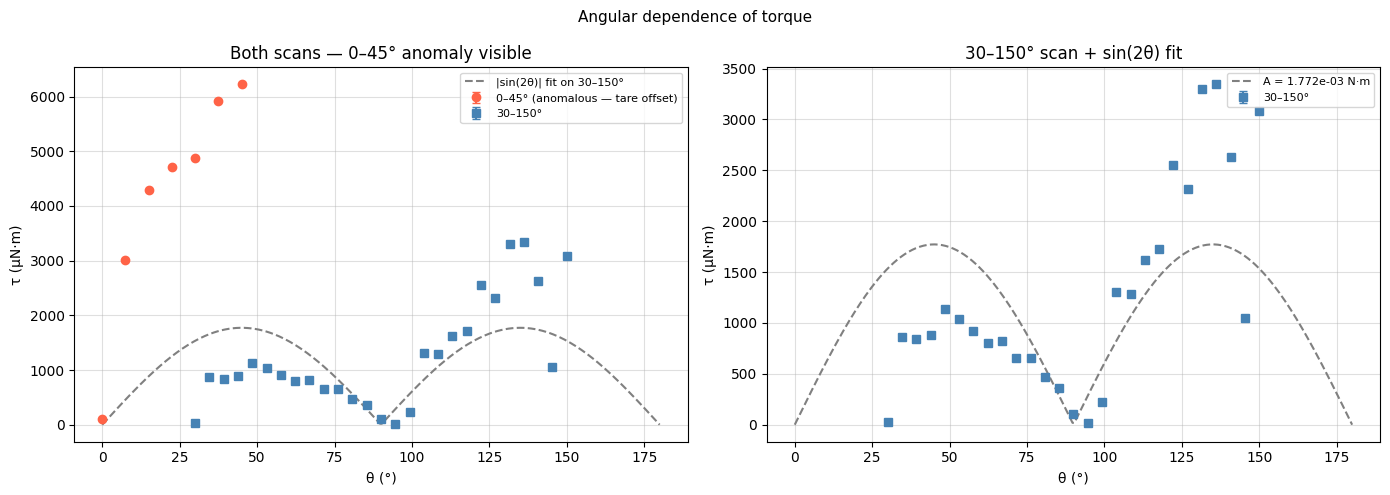

Saved: torque_angle_check.png
Fit amplitude A = 1.772e-03 N·m


In [15]:
f1 = 'torqueangles_0to45.csv'
f2 = 'torqueangles_30to150.csv'

if not (os.path.exists(f1) and os.path.exists(f2)):
    print(f'Angle CSVs not found — skipping.')
    print(f'Place {f1} and {f2} in working directory and re-run.')
else:
    a1 = pd.read_csv(f1, sep=',', header=None)
    a2 = pd.read_csv(f2, sep=',', header=None)

    def sem(x): return x.std(ddof=1)/np.sqrt(x.count())
    s1 = pd.DataFrame({'mean': a1.mean(), 'sem': a1.apply(sem)})
    s2 = pd.DataFrame({'mean': a2.mean(), 'sem': a2.apply(sem)})

    vtau = lambda V: R_LEVER * np.abs(V) / SLOPE_V_PER_N

    # Update these arrays to your actual recorded angles
    th1 = np.linspace(0,  45,  len(s1))
    th2 = np.linspace(30, 150, len(s2))

    t1, e1 = vtau(s1['mean'].values), vtau(s1['sem'].values)
    t2, e2 = vtau(s2['mean'].values), vtau(s2['sem'].values)

    # Fit only on 30-150 (0-45 is anomalous due to tare offset)
    sin2 = lambda th, A: A * np.abs(np.sin(2*np.radians(th)))
    pA, _ = curve_fit(sin2, th2, t2)
    th_fine = np.linspace(0, 180, 300)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: both scans overlaid
    axes[0].errorbar(th1, t1*1e6, yerr=e1*1e6, fmt='o', color='tomato',
                     capsize=3, label='0–45° (anomalous — tare offset)')
    axes[0].errorbar(th2, t2*1e6, yerr=e2*1e6, fmt='s', color='steelblue',
                     capsize=3, label='30–150°')
    axes[0].plot(th_fine, sin2(th_fine, *pA)*1e6, '--', color='gray',
                 label=f'|sin(2θ)| fit on 30–150°')
    axes[0].set_xlabel('θ (°)'); axes[0].set_ylabel('τ (µN·m)')
    axes[0].set_title('Both scans — 0–45° anomaly visible')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

    # Right: 30-150 only with fit
    axes[1].errorbar(th2, t2*1e6, yerr=e2*1e6, fmt='s', color='steelblue',
                     capsize=3, label='30–150°')
    axes[1].plot(th_fine, sin2(th_fine, *pA)*1e6, '--', color='gray',
                 label=f'A = {pA[0]:.3e} N·m')
    axes[1].set_xlabel('θ (°)'); axes[1].set_ylabel('τ (µN·m)')
    axes[1].set_title('30–150° scan + sin(2θ) fit')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

    plt.suptitle('Angular dependence of torque', fontsize=11)
    plt.tight_layout()
    plt.savefig('torque_angle_check.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: torque_angle_check.png')
    print(f'Fit amplitude A = {pA[0]:.3e} N·m')

---
## 12. Clinical projection — τ vs rod length

### Gravitational torque reference (ASTM F2213-17 / Woods et al.)

ASTM F2213-17 (§7.4, Eq. 4–5) defines a conservative acceptance criterion:
the magnetically induced torque must not exceed the gravitational torque,
estimated as $\tau_{\rm grav} = mgL$, where $L$ is the longest linear dimension.

For a uniform cylinder (volume $V = \pi(d/2)^2 L$, mass $m = \rho V$):

$$\tau_{\rm mag} = \frac{\chi_m V}{2\mu_0}B^2 \propto L$$

$$\tau_{\rm grav} = mgL = \rho\,\frac{\pi d^2}{4}\,g\,L^2 \propto L^2$$

Setting them equal and cancelling $\pi d^2/4$ (diameter drops out):

$$L^* = \frac{\chi_m B^2}{2\mu_0 \rho g}$$

For $L < L^*$: $\tau_{\rm mag} > \tau_{\rm grav}$ — fails criterion.  
For $L > L^*$: $\tau_{\rm mag} < \tau_{\rm grav}$ — passes criterion.

### Susceptibility values used

| Material | $\chi_m$ | Source |
|----------|---------|--------|
| Ferromag. ref (lab rods) | from quadratic fit (§9) | this work |
| 316L SS (implant-grade, ASTM F138-13a) | back-calculated from Woods Table 2: $\theta=8.8°$, $B=1.22$ T, $|\nabla B|=3.78$ T/m | Woods et al. 2021 |
| Ti (pure element) | $1.807\times10^{-4}$ | periodictable.com (CRC Handbook) |

316L back-calculation:  
$\mathrm{FR} = \tan(8.8°) = 0.1548$,  
$\chi_{316L} = \mathrm{FR}\cdot\mu_0\rho g\,/\,(B\cdot|\nabla B|) = 3.27\times10^{-3}$

**Note:** this is implant-grade 316L (no delta ferrite). Non-implant-grade 316L
can have substantially higher $\chi$ due to deformation-induced martensite (Woods et al.).

### Reading the plots
- Solid lines: $\tau_{\rm mag}$ per diameter and material.
- Dashed lines (same color): $\tau_{\rm grav} = mgL$ for the same diameter.
- Grey dotted: $\tau_{\rm min}$ — measured sensor detection floor.
- Purple verticals: $L^*$ crossover (only shown when it falls in the plotted range).
- $\bigstar$ = short lab rod (2 cm, 5 mm ⌀); $\Diamond$ = long lab rod (22 cm, 10 mm ⌀),
  filled for $\tau_{\rm mag}$, open for $\tau_{\rm grav}$.

**Field values:** 0.5 T at ~0.4 m from bore face (from field mapping session);
3.0 T nominal isocenter (scanner specification, not directly measured).


chi_316L = 3.2693e-03  (from Woods Table 2, implant-grade ASTM F138-13a)
chi_Ti   = 1.8070e-04  (periodictable.com, pure Ti)
chi_SR   = 112.3       (ferromag. ref, quadratic fit, this work)



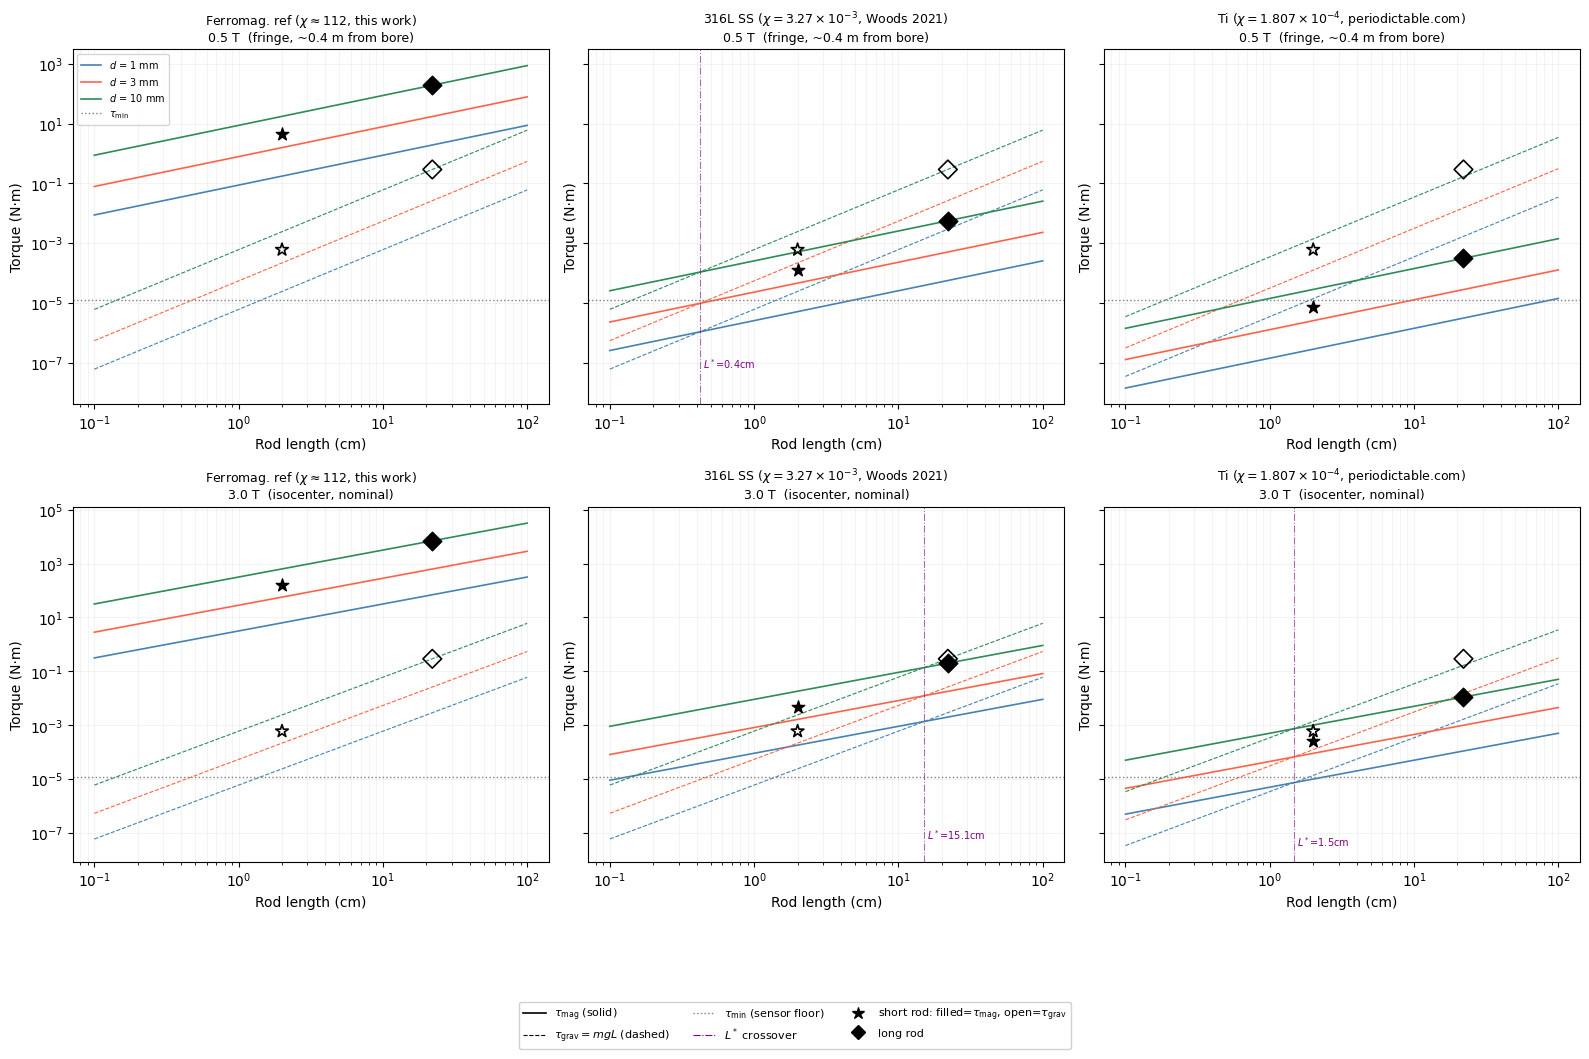

Saved: torque_clinical_projection.png

L* (cm) — crossover length where tau_mag = tau_grav
(diameter cancels; L* depends only on chi, B, rho)
Material                                    B (T)        L* (cm)
------------------------------------------------------------------
Ferromag. ref ($\chi\approx112$, this work)  0.5            >100m
Ferromag. ref ($\chi\approx112$, this work)  3.0            >100m

316L SS ($\chi=3.27\times10^{-3}$, Woods 2021)  0.5             0.42
316L SS ($\chi=3.27\times10^{-3}$, Woods 2021)  3.0            15.11

Ti ($\chi=1.807\times10^{-4}$, periodictable.com)  0.5             0.04
Ti ($\chi=1.807\times10^{-4}$, periodictable.com)  3.0             1.46


Predicted tau_mag at B=0.5T, L=20cm, d=4mm:
  Ferromag. ref ($\chi\approx112$, this work): tau_mag=2.807e+01 Nm  (2268456.9x floor)  tau_grav=3.871e-02 Nm  ratio=725.282
  316L SS ($\chi=3.27\times10^{-3}$, Woods 2021): tau_mag=8.173e-04 Nm  (66.0x floor)  tau_grav=3.896e-02 Nm  ratio=0.021
  Ti ($\chi=1.80

In [16]:
import numpy as np
from matplotlib.lines import Line2D

# ── Material densities ────────────────────────────────────────────────────────
rho_steel = 7850    # kg/m3  mild/carbon steel (ferromag. ref rods)
rho_316L  = 7900    # kg/m3  316L SS #https://www.ametek.com/-/media/ameteksuperiortube/files/downloads/alloy-data-sheets/alloy316l.pdf?la=en&revision=26c988b2-1faf-4a51-9050-814eeba3c11d
rho_Ti    = 4507    # kg/m3  pure titanium
g_acc     = 9.81    # m/s2

# ── Susceptibility values ─────────────────────────────────────────────────────
# 316L: back-calculated from Woods et al. Table 2
#   theta=8.8deg, B=1.22T, grad_B=3.78 T/m, rho_316L=7900 kg/m3
FR_316L  = np.tan(np.radians(8.8))
chi_316L = FR_316L * mu0 * rho_316L * g_acc / (1.22 * 3.78)
print(f'chi_316L = {chi_316L:.4e}  (from Woods Table 2, implant-grade ASTM F138-13a)')

# Ti: periodictable.com (CRC Handbook), pure element
chi_Ti_elem = 1.807e-4
print(f'chi_Ti   = {chi_Ti_elem:.4e}  (periodictable.com, pure Ti)')
print(f'chi_SR   = {chi_SR:.1f}       (ferromag. ref, quadratic fit, this work)')
print()

# ── Helper functions ──────────────────────────────────────────────────────────
def tau_mag(chi, L, d, B, theta=45):
    Vol = np.pi*(d/2)**2*L
    return chi*Vol/(2*mu0)*B**2*np.sin(2*np.radians(theta))

def tau_grav(L, d, rho):
    """tau_grav = m*g*L  (ASTM F2213-17 conservative reference)"""
    return rho * np.pi*(d/2)**2 * L * g_acc * L

def L_cross(chi, B, rho):
    """L* where tau_mag = tau_grav; diameter cancels."""
    return chi * B**2 / (2 * mu0 * rho * g_acc)

# ── Plot setup ────────────────────────────────────────────────────────────────
mats = [
    (f'Ferromag. ref ($\\chi\\approx{chi_SR:.0f}$, this work)',
     chi_SR, rho_steel),
    ('316L SS ($\\chi=3.27\\times10^{-3}$, Woods 2021)',
     chi_316L, rho_316L),
    ('Ti ($\\chi=1.807\\times10^{-4}$, periodictable.com)',
     chi_Ti_elem, rho_Ti),
]
diams  = [('1 mm', 0.001), ('3 mm', 0.003), ('10 mm', 0.010)]
fields = [('0.5 T  (fringe, ~0.4 m from bore)', 0.5),
          ('3.0 T  (isocenter, nominal)',         3.0)]
Ls     = np.logspace(-3, 0, 400)    # 1 mm – 1 m
colors = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey='row')

for row, (Bl, B) in enumerate(fields):
    for col, (ml, chi, rho) in enumerate(mats):
        ax = axes[row][col]

        for (dl, d), c in zip(diams, colors):
            ax.loglog(Ls*100, tau_mag(chi, Ls, d, B),
                      color=c, lw=1.2, label=f'$d$ = {dl}')
            ax.loglog(Ls*100, tau_grav(Ls, d, rho),
                      color=c, lw=0.8, ls='--')

        ax.axhline(tau_min, color='grey', lw=1, ls=':', label=r'$\tau_{\rm min}$')

        # Lab rod markers: filled = tau_mag, open = tau_grav
        for tL, td, rho_rod, mk in [
            (0.02, 0.005, rho_steel, '*'),   # short rod
            (0.22, 0.010, rho_steel, 'D'),   # long rod
        ]:
            ax.scatter([tL*100], [tau_mag(chi, tL, td, B)],
                       marker=mk, s=90, color='k', zorder=6)
            ax.scatter([tL*100], [tau_grav(tL, td, rho_rod)],
                       marker=mk, s=90, color='k', facecolors='none',
                       linewidths=1.2, zorder=6)

        # L* vertical lines (only if in plotted range)
        Lc = L_cross(chi, B, rho) * 100   # cm
        if 0.1 < Lc < 100:
            ax.axvline(Lc, color='purple', lw=0.8, ls='-.', alpha=0.6)
            ax.text(Lc*1.05, ax.get_ylim()[0]*3, f'$L^*$={Lc:.1f}cm',
                    color='purple', fontsize=7, va='bottom')

        ax.set_xlabel('Rod length (cm)')
        ax.set_ylabel('Torque (N·m)')
        ax.set_title(f'{ml}\n{Bl}', fontsize=9)
        ax.grid(True, which='both', alpha=0.25, lw=0.4)

        if row == 0 and col == 0:
            ax.legend(fontsize=7)

# Shared legend
leg_elements = [
    Line2D([0],[0], color='k', lw=1.2,
           label=r'$\tau_{\rm mag}$ (solid)'),
    Line2D([0],[0], color='k', lw=0.8, ls='--',
           label=r'$\tau_{\rm grav}=mgL$ (dashed)'),
    Line2D([0],[0], color='grey', lw=1, ls=':',
           label=r'$\tau_{\rm min}$ (sensor floor)'),
    Line2D([0],[0], color='purple', lw=0.8, ls='-.',
           label=r'$L^*$ crossover'),
    Line2D([0],[0], marker='*', color='k', ls='none', ms=9,
           label='short rod: filled=$\\tau_{\\rm mag}$, open=$\\tau_{\\rm grav}$'),
    Line2D([0],[0], marker='D', color='k', ls='none', ms=7,
           label='long rod'),
]
fig.legend(handles=leg_elements, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.06),
           framealpha=0.9)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('torque_clinical_projection.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: torque_clinical_projection.png')

# ── Crossover table ───────────────────────────────────────────────────────────
print()
print('L* (cm) — crossover length where tau_mag = tau_grav')
print('(diameter cancels; L* depends only on chi, B, rho)')
print(f'{"Material":42s}  {"B (T)":8s}  {"L* (cm)":>10s}')
print('-'*66)
for ml, chi, rho in mats:
    for Bl, B in fields:
        Lc = L_cross(chi, B, rho) * 100
        val = f'{Lc:.2f}' if Lc < 10000 else '>100m'
        print(f'{ml:42s}  {B:<8.1f}  {val:>10s}')
    print()

# ── Numerical predictions at clinical fringe ──────────────────────────────────
print()
print('Predicted tau_mag at B=0.5T, L=20cm, d=4mm:')
for ml, chi, rho in mats:
    tm = tau_mag(chi, 0.20, 0.004, 0.5)
    tg = tau_grav(0.20, 0.004, rho)
    print(f'  {ml}: tau_mag={tm:.3e} Nm  '
          f'({tm/tau_min:.1f}x floor)  '
          f'tau_grav={tg:.3e} Nm  '
          f'ratio={tm/tg:.3f}')


---
## 14. Minimum detectable rod length

Solving the torque equation for $L_{\rm min}$:
$$\tau_{\rm min} = \frac{\chi_m \pi(d/2)^2 L_{\rm min}}{2\mu_0} B^2
\implies L_{\rm min} = \frac{2\mu_0 \tau_{\rm min}}{\chi_m \pi(d/2)^2 B^2}$$

**'Reachable (L < 30cm)?'** means the minimum detectable length is short enough that
a bench-top or clinical rod of that material and diameter could plausibly be made and tested.

In [17]:
def L_min(chi, d, B):
    return (2*mu0*tau_min) / (chi * np.pi*(d/2)**2 * B**2)

rows = []
for chi_v, mn in [(2.0, '316L SS (χ≈2)'),
                   (chi_SR, f'Ferromag. ref (χ≈{chi_SR:.0f})')]:
    for B in [0.5, 3.0]:
        for d_mm in [1, 3, 5, 10]:
            L = L_min(chi_v, d_mm/1000, B)
            rows.append({
                'Material':        mn,
                'B (T)':           B,
                'd (mm)':          d_mm,
                'L_min (cm)':      round(L*100, 2),
                'L_min < 30 cm?': 'Yes' if L*100 < 30 else 'No (too long)',
            })

df_L = pd.DataFrame(rows)
print(df_L.to_string(index=False))
df_L.to_csv('torque_mindetectable.csv', index=False)
print('\nSaved: torque_mindetectable.csv')
print('\nRows marked No → that material/diameter combination cannot produce detectable')
print('torque even with a 30cm rod. Needs either stronger field, larger diameter,')
print('or more ferromagnetic material.')

             Material  B (T)  d (mm)  L_min (cm) L_min < 30 cm?
        316L SS (χ≈2)    0.5       1        0.01            Yes
        316L SS (χ≈2)    0.5       3        0.00            Yes
        316L SS (χ≈2)    0.5       5        0.00            Yes
        316L SS (χ≈2)    0.5      10        0.00            Yes
        316L SS (χ≈2)    3.0       1        0.00            Yes
        316L SS (χ≈2)    3.0       3        0.00            Yes
        316L SS (χ≈2)    3.0       5        0.00            Yes
        316L SS (χ≈2)    3.0      10        0.00            Yes
Ferromag. ref (χ≈112)    0.5       1        0.00            Yes
Ferromag. ref (χ≈112)    0.5       3        0.00            Yes
Ferromag. ref (χ≈112)    0.5       5        0.00            Yes
Ferromag. ref (χ≈112)    0.5      10        0.00            Yes
Ferromag. ref (χ≈112)    3.0       1        0.00            Yes
Ferromag. ref (χ≈112)    3.0       3        0.00            Yes
Ferromag. ref (χ≈112)    3.0       5    

---
## 15. Results summary table

In [18]:
rows = [
    ('Calibration slope [V/N]',       f'{SLOPE_V_PER_N:.4e}',                                'Rod 3 Al sesorcal'),
    ('Lever arm r [m]',               f'{R_LEVER}',                                           'fixed'),
    ('Detection ΔV [mV]',             f'{delta_V_min*1e3:.3f}',                               'sesorcal min non-zero ΔV'),
    ('Detection F [µN]',              f'{F_min*1e6:.2f}',                                     'F = ΔV / slope'),
    ('Detection τ_min [N·m]',         f'{tau_min:.3e}',                                       'τ = r × F'),
    ('k LR ZI [N·m/T²]',             f'{popt_LR_zi[0]:.4e} ± {perr_LR_zi[0]:.4e}',          'hLR2, zero-intercept'),
    ('k LR quad [N·m/T²]',           f'{popt_LR_q[0]:.4e} ± {perr_LR_q[0]:.4e}',            'hLR2, quadratic'),
    ('k SR ZI [N·m/T²]',             f'{popt_nSR_zi[0]:.4e} ± {perr_nSR_zi[0]:.4e}',        'nSR, zero-intercept'),
    ('k SR quad [N·m/T²]',           f'{popt_nSR_q[0]:.4e} ± {perr_nSR_q[0]:.4e}',          'nSR, quadratic'),
    ('χ_m LR (ZI)',                   f'{chi_LR_zi:.3f} ± {chi_LR_zi_err:.3f}',              ''),
    ('χ_m LR (quadratic) — primary', f'{chi_LR_q:.3f} ± {chi_LR_q_err:.3f}',               'used for projection'),
    ('χ_m SR (ZI)',                   f'{chi_SR_zi:.3f} ± {chi_SR_zi_err:.3f}',              ''),
    ('χ_m SR (quadratic) — primary', f'{chi_SR_q:.3f} ± {chi_SR_q_err:.3f}',               'used for projection'),
]
df_s = pd.DataFrame(rows, columns=['Metric','Value','Notes'])
print(df_s.to_string(index=False))
df_s.to_csv('torque_results_summary.csv', index=False)
print('\nSaved: torque_results_summary.csv')

                      Metric                   Value                    Notes
     Calibration slope [V/N]              3.5754e+00        Rod 3 Al sesorcal
             Lever arm r [m]                    0.05                    fixed
           Detection ΔV [mV]                   0.885 sesorcal min non-zero ΔV
            Detection F [µN]                  247.52           F = ΔV / slope
       Detection τ_min [N·m]               1.238e-05                τ = r × F
            k LR ZI [N·m/T²] 3.7936e+02 ± 8.6277e+00     hLR2, zero-intercept
          k LR quad [N·m/T²] 3.8655e+02 ± 4.9732e+01          hLR2, quadratic
            k SR ZI [N·m/T²] 7.0080e+00 ± 2.4030e-01      nSR, zero-intercept
          k SR quad [N·m/T²] 1.7547e+01 ± 3.2740e+00           nSR, quadratic
                 χ_m LR (ZI)         220.716 ± 5.020                         
χ_m LR (quadratic) — primary        224.903 ± 28.935      used for projection
                 χ_m SR (ZI)          44.851 ± 1.538            

---
## Notes for Results / Discussion

**ZI vs quadratic k (§8):**
ZI = zero-intercept fit (τ = kB²). When a non-zero offset V₀ is present the ZI model
absorbs part of the offset into k, biasing it downward. When V₀ is genuine noise
(as in hSR2 where V₀ ≪ τ_min) both models give equivalent information.
Both are retained here because the k discrepancy (ZI vs quadratic) directly motivates
the circuit improvement described in §10.

**χ_m interpretation:**
The calibration rods are ferromagnetic steel, not 316L. The measured χ values
(56–113) are consistent with low-grade ferromagnetic alloys and are used as
order-of-magnitude scaling tools for the clinical projection, not as precise
material characterisation. Independent verification (VSM or SQUID) would be
needed to pin these values down.

**Angle scan (§11):**
Not part of the formal methodology. The 30–150° scan is broadly consistent with
sin(2θ); the 0–45° anomaly is attributed to a tare error. Neither scan is
reported in Results.

**Clinical projection (§12–13):**
Contingent on χ reliability (factor-of-two uncertainty). Treat as planning tool
for future sample selection, not a quantitative result.

**Where to edit notebook prose:**
All explanatory text appears in `markdown` cells. In JupyterLab: double-click any
markdown cell to edit, Shift+Enter to render. Code cell comments (lines starting `#`)
can be edited the same way.

**Minimal-style figures for LaTeX (§16):**
Section 16 below regenerates the key publication figures with no title,
minimal axis labels, and no internal text boxes — ready for inclusion in the
Results section alongside the LaTeX captions.


---
## 16. Publication figures — minimal style (LaTeX-ready)

No titles. Minimal axis text. No in-plot text boxes.
Captions are handled in LaTeX. Files saved as high-res PNG.


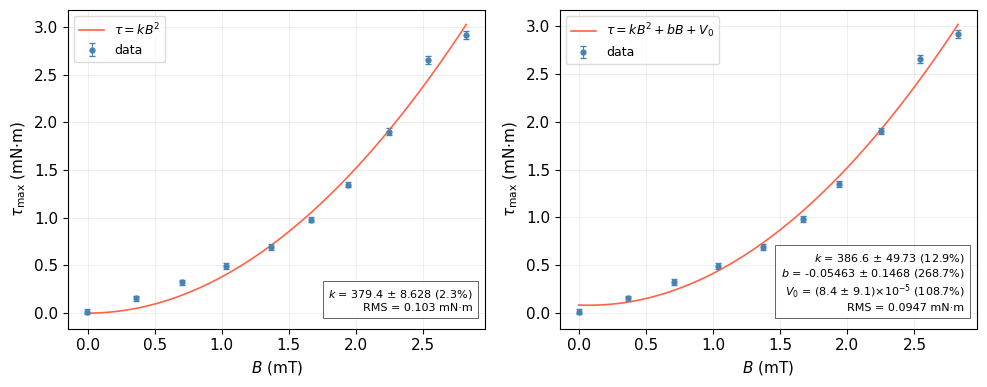

Saved: fig_torque_LR.png


In [19]:
# ── CELL 39  id=cell-16a ── Fig A: Long rod Helmholtz
plt.rcParams.update({'font.size': 11, 'axes.linewidth': 0.8,
                     'xtick.major.width': 0.8, 'ytick.major.width': 0.8})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xfit_LR = np.linspace(x_LR.min(), x_LR.max(), 300)

for ax, popt, perr, fn, pnames, rms, label in [
    (axes[0], popt_LR_zi, perr_LR_zi, fn_LR_zi, pnames_LR_zi, rms_LR_zi,
     r'$\tau = kB^2$'),
    (axes[1], popt_LR_q,  perr_LR_q,  fn_LR_q,  pnames_LR_q,  rms_LR_q,
     r'$\tau = kB^2 + bB + V_0$'),
]:
    ax.errorbar(x_LR*1e3, y_LR*1e3, yerr=df_LR['sigma_tau']*1e3,
                fmt='o', ms=3.5, capsize=2.5, color='steelblue',
                ecolor='steelblue', elinewidth=0.8, label='data')
    ax.plot(xfit_LR*1e3, fn(xfit_LR, *popt)*1e3, '-', color='tomato',
            linewidth=1.2, label=label)
    ax.set_xlabel(r'$B$ (mT)')
    ax.set_ylabel(r'$\tau_{\rm max}$ (mN$\cdot$m)')
    ax.legend(fontsize=9, framealpha=0.7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Annotation — values in raw SI, formatted like the paper
    lines = []
    for n, v, e in zip(pnames, popt, perr):
        pct = e / abs(v) * 100
        if n == 'k':
            lines.append(rf'$k$ = {v:.4g} $\pm$ {e:.4g} ({pct:.1f}%)')
        elif n == 'b':
            lines.append(rf'$b$ = {v:.4g} $\pm$ {e:.4g} ({pct:.1f}%)')
        elif n == 'V0':
            exp = int(np.floor(np.log10(abs(v)))) if v != 0 else 0
            mant = v / 10**exp
            e_exp = int(np.floor(np.log10(abs(e)))) if e != 0 else 0
            e_mant = e / 10**exp   # same exponent as v for clean reading
            lines.append(rf'$V_0$ = ({mant:.3g} $\pm$ {e_mant:.2g})$\times10^{{{exp}}}$ ({pct:.1f}%)')
    lines.append(rf'RMS = {rms*1e3:.3g} mN·m')

    ax.text(0.97, 0.05, '\n'.join(lines), transform=ax.transAxes,
            va='bottom', ha='right', fontsize=8,
            bbox=dict(fc='white', alpha=0.85, lw=0.5))

plt.tight_layout()
plt.savefig('fig_torque_LR.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_torque_LR.png')

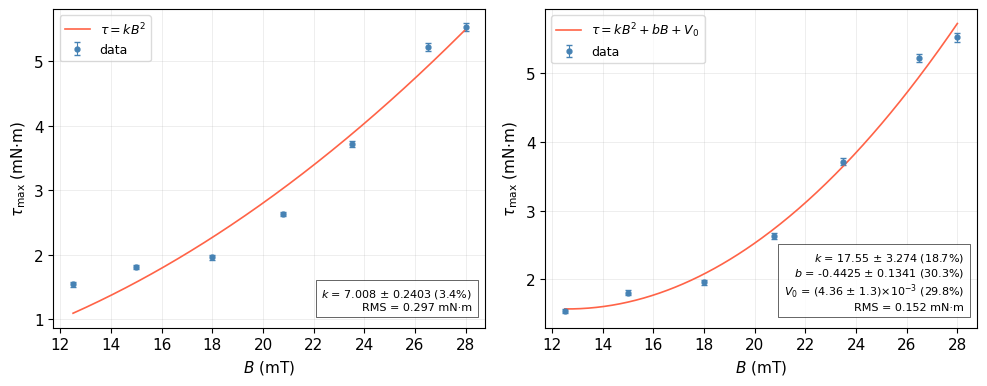

Saved: fig_torque_SR_neo.png


In [20]:
# ── CELL 40  id=cell-16b ── Fig B: Short rod Neodymium
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xfit_n = np.linspace(x_nSR.min(), x_nSR.max(), 300)

for ax, popt, perr, fn, pnames, rms, label in [
    (axes[0], popt_nSR_zi, perr_nSR_zi, fn_nSR_zi, pnames_nSR_zi, rms_nSR_zi,
     r'$\tau = kB^2$'),
    (axes[1], popt_nSR_q,  perr_nSR_q,  fn_nSR_q,  pnames_nSR_q,  rms_nSR_q,
     r'$\tau = kB^2 + bB + V_0$'),
]:
    ax.errorbar(x_nSR*1e3, y_nSR*1e3, yerr=df_nSR['sigma_tau']*1e3,
                fmt='o', ms=3.5, capsize=2.5, color='steelblue',
                ecolor='steelblue', elinewidth=0.8, label='data')
    ax.plot(xfit_n*1e3, fn(xfit_n, *popt)*1e3, '-', color='tomato',
            linewidth=1.2, label=label)
    ax.set_xlabel(r'$B$ (mT)')
    ax.set_ylabel(r'$\tau_{\rm max}$ (mN$\cdot$m)')
    ax.legend(fontsize=9, framealpha=0.7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    lines = []
    for n, v, e in zip(pnames, popt, perr):
        pct = e / abs(v) * 100
        if n == 'k':
            lines.append(rf'$k$ = {v:.4g} $\pm$ {e:.4g} ({pct:.1f}%)')
        elif n == 'b':
            lines.append(rf'$b$ = {v:.4g} $\pm$ {e:.4g} ({pct:.1f}%)')
        elif n == 'V0':
            exp = int(np.floor(np.log10(abs(v)))) if v != 0 else 0
            mant = v / 10**exp
            e_exp = int(np.floor(np.log10(abs(e)))) if e != 0 else 0
            e_mant = e / 10**exp   # same exponent as v for clean reading
            lines.append(rf'$V_0$ = ({mant:.3g} $\pm$ {e_mant:.2g})$\times10^{{{exp}}}$ ({pct:.1f}%)')
    lines.append(rf'RMS = {rms*1e3:.3g} mN·m')

    ax.text(0.97, 0.05, '\n'.join(lines), transform=ax.transAxes,
            va='bottom', ha='right', fontsize=8,
            bbox=dict(fc='white', alpha=0.85, lw=0.5))

plt.tight_layout()
plt.savefig('fig_torque_SR_neo.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_torque_SR_neo.png')

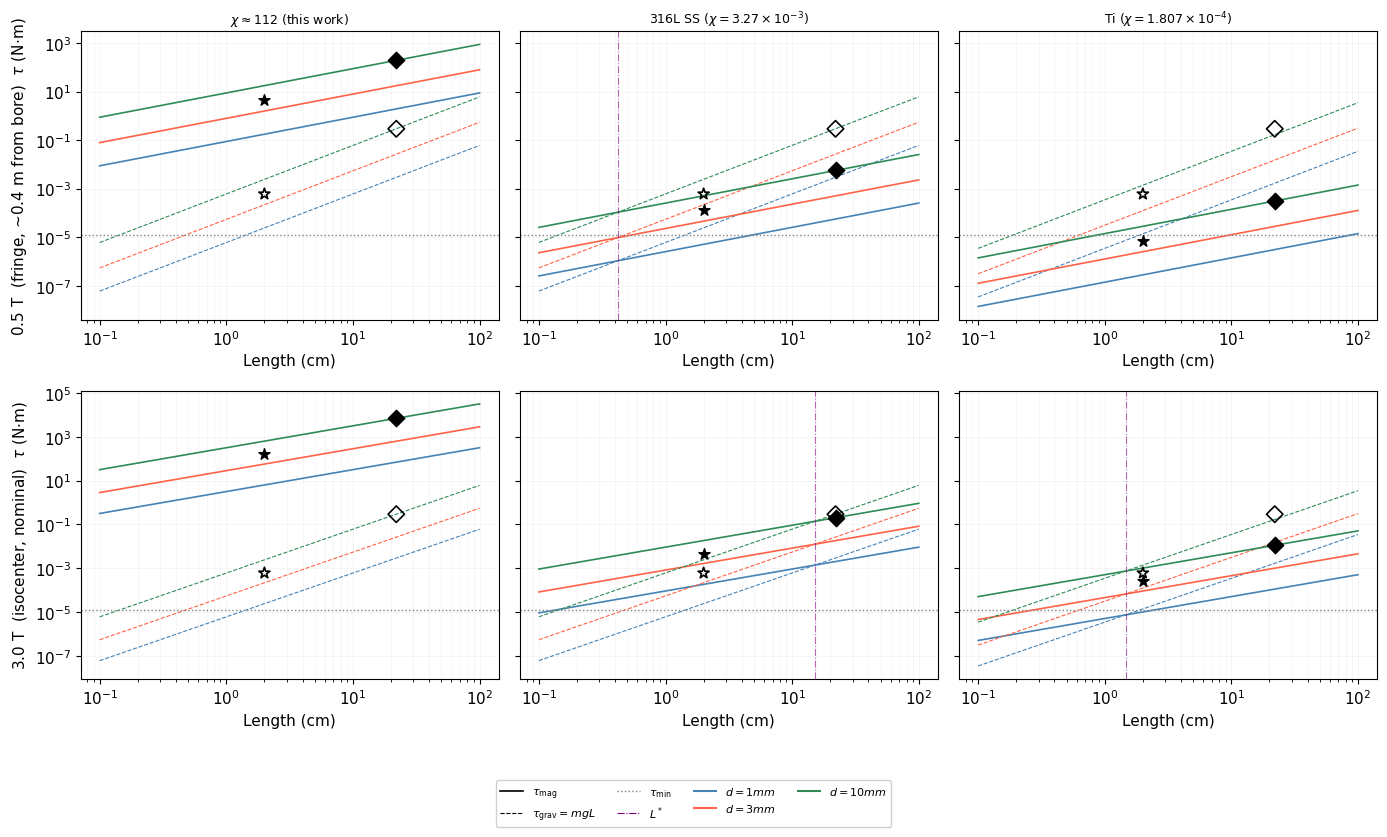

Saved: fig_torque_projection.png


In [21]:
# Fig C: Clinical projection — minimal style for LaTeX
# Uses corrected chi values: 316L from Woods, Ti from periodictable.com
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row')

mats_pub = [
    (f'$\\chi\\approx{chi_SR:.0f}$ (this work)', chi_SR, rho_steel),
    ('316L SS ($\\chi=3.27\\times10^{-3}$)',      chi_316L, rho_316L),
    ('Ti ($\\chi=1.807\\times10^{-4}$)',           chi_Ti_elem, rho_Ti),
]
Ls = np.logspace(-3, 0, 400)
colors = ['steelblue', 'tomato', 'seagreen']

for row, (Bl, B) in enumerate(fields):
    for col, (ml, chi, rho) in enumerate(mats_pub):
        ax = axes[row][col]
        for (dl, d), c in zip(diams, colors):
            ax.loglog(Ls*100, tau_mag(chi, Ls, d, B),  color=c, lw=1.2)
            ax.loglog(Ls*100, tau_grav(Ls, d, rho),    color=c, lw=0.8, ls='--')
        ax.axhline(tau_min, color='grey', lw=1, ls=':')
        Lc = L_cross(chi, B, rho) * 100
        if 0.1 < Lc < 100:
            ax.axvline(Lc, color='purple', lw=0.8, ls='-.', alpha=0.6)
        for tL, td, rho_rod, mk in [(0.02,0.005,rho_steel,'*'),
                                     (0.22,0.010,rho_steel,'D')]:
            ax.scatter([tL*100], [tau_mag(chi,tL,td,B)],
                       marker=mk, s=70, color='k', zorder=6)
            ax.scatter([tL*100], [tau_grav(tL,td,rho_rod)],
                       marker=mk, s=70, color='k', facecolors='none',
                       linewidths=1.2, zorder=6)
        ax.set_xlabel('Length (cm)')
        ax.grid(True, which='both', alpha=0.2, lw=0.4)
        if row == 0: ax.set_title(ml, fontsize=9)
        if col == 0: ax.set_ylabel(Bl + r'  $\tau$ (N$\cdot$m)')

leg = [
    Line2D([0],[0], color='k', lw=1.2, label=r'$\tau_{\rm mag}$'),
    Line2D([0],[0], color='k', lw=0.8, ls='--', label=r'$\tau_{\rm grav}=mgL$'),
    Line2D([0],[0], color='grey', lw=1, ls=':', label=r'$\tau_{\rm min}$'),
    Line2D([0],[0], color='purple', lw=0.8, ls='-.', label=r'$L^*$'),
]
for (dl,d),c in zip(diams,colors):
    leg.append(Line2D([0],[0], color=c, lw=1.5, label=f'$d={dl}$'))
fig.legend(handles=leg, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.05), framealpha=0.9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('fig_torque_projection.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_torque_projection.png')